In [1]:
# Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, auc)
from sklearn.base import clone

In [2]:
# Load data and create scenario groups
DATA_PATH = r'C:\\Users\\manur\\OneDrive\\Documents\\Multi_Crop_Ranking_\\Multi_Crop_Ranking\\Notebooks\\Models\\Crop_training_data_FULL_F1.csv'
df = pd.read_csv(DATA_PATH)

ENV_COLS = [
    'temperature', 'rainfall', 'sunshine_hours',
    'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'
]

rounded = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded, index=False).astype('int64')

In [3]:
# Prepare features and target
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0}).astype(int)
DROP_COLS = ['suitability_class', 'suitability', 'texture', 'rooting_depth_m']
X = df.drop(columns=DROP_COLS)
groups = df['scenario_id']

categorical_cols = ['crop']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

In [4]:
# Train/test split by scenario
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train scenarios: {g_train.nunique()}, Test scenarios: {g_test.nunique()}')

Train: (1680, 11), Test: (420, 11)
Train scenarios: 1680, Test scenarios: 420


In [5]:
# Define preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

In [6]:
# Baseline Random Forest
baseline_pipe = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', RandomForestClassifier(random_state=42))
])

baseline_pipe.fit(X_train, y_train)

baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

baseline_roc = roc_auc_score(y_test, baseline_proba)
baseline_pr = average_precision_score(y_test, baseline_proba)

print("=== Baseline Random Forest ===")
print(f"ROC-AUC: {baseline_roc:.4f}")
print(f"PR-AUC:  {baseline_pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))
print("\nClassification Report:")
print(classification_report(y_test, baseline_pred, digits=3))

=== Baseline Random Forest ===
ROC-AUC: 0.9202
PR-AUC:  0.9454

Confusion Matrix:
[[126  48]
 [ 24 222]]

Classification Report:
              precision    recall  f1-score   support

           0      0.840     0.724     0.778       174
           1      0.822     0.902     0.860       246

    accuracy                          0.829       420
   macro avg      0.831     0.813     0.819       420
weighted avg      0.830     0.829     0.826       420



In [7]:
# # Expanded hyperparameter tuning with GridSearchCV
# pipe = Pipeline(steps=[('preprocess', preprocessor),
#                        ('model', RandomForestClassifier(random_state=42))])

# # Expanded parameter grid
# param_grid = {
#     'model__n_estimators': [200, 400, 600, 800],
#     'model__max_depth': [None, 10, 20, 30],
#     'model__min_samples_split': [2, 5, 10],
#     'model__min_samples_leaf': [1, 2, 4],
#     'model__max_features': ['sqrt', 'log2', None],
#     'model__class_weight': [None, 'balanced', 'balanced_subsample']
# }

# cv = GroupKFold(n_splits=5)
# gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
# gs.fit(X_train, y_train, groups=g_train)

# print("\nBest CV ROC-AUC: {:.4f}".format(gs.best_score_))
# print("Best parameters:")
# print(gs.best_params_)

In [8]:
# Expanded hyperparameter tuning with GridSearchCV
pipe = Pipeline(steps=[('preprocess', preprocessor),
                       ('model', RandomForestClassifier(random_state=42))])

# Expanded parameter grid
param_grid = {
    'model__n_estimators': [200, 400, 600, 800],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 3],
    'model__max_features': ['sqrt', 'log2', None],
    'model__class_weight': [None, 'balanced']
}

# Combinations = 4×4×3×3×3×2 = 648
# Total fits (5‑fold CV) = 648 × 5 = 3240

cv = GroupKFold(n_splits=5)
gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train, groups=g_train)

print("\nBest CV ROC-AUC: {:.4f}".format(gs.best_score_))
print("Best parameters:")
print(gs.best_params_)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits

Best CV ROC-AUC: 0.9319
Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 30, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 800}


In [9]:
# Evaluate tuned model on test set
best_model = gs.best_estimator_
tuned_proba = best_model.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_proba >= 0.5).astype(int)

tuned_roc = roc_auc_score(y_test, tuned_proba)
tuned_pr = average_precision_score(y_test, tuned_proba)

print("=== Tuned Random Forest ===")
print(f"ROC-AUC: {tuned_roc:.4f}")
print(f"PR-AUC:  {tuned_pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_pred, digits=3))

=== Tuned Random Forest ===
ROC-AUC: 0.9297
PR-AUC:  0.9554

Confusion Matrix:
[[136  38]
 [ 30 216]]

Classification Report:
              precision    recall  f1-score   support

           0      0.819     0.782     0.800       174
           1      0.850     0.878     0.864       246

    accuracy                          0.838       420
   macro avg      0.835     0.830     0.832       420
weighted avg      0.838     0.838     0.837       420



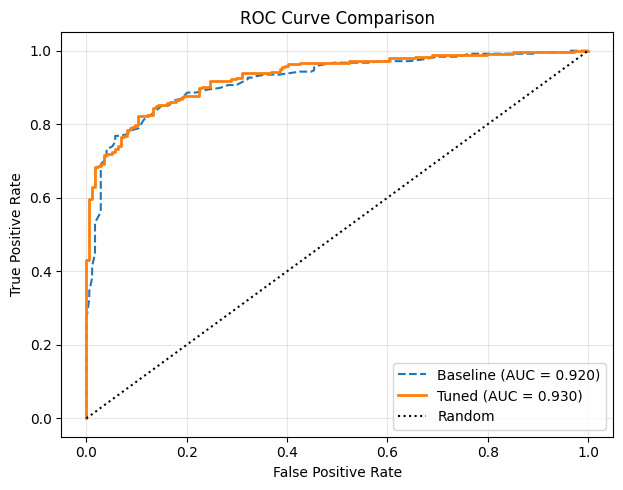

In [10]:
# Comparison plots (Baseline vs Tuned)

# ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {baseline_roc:.3f})', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {tuned_roc:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

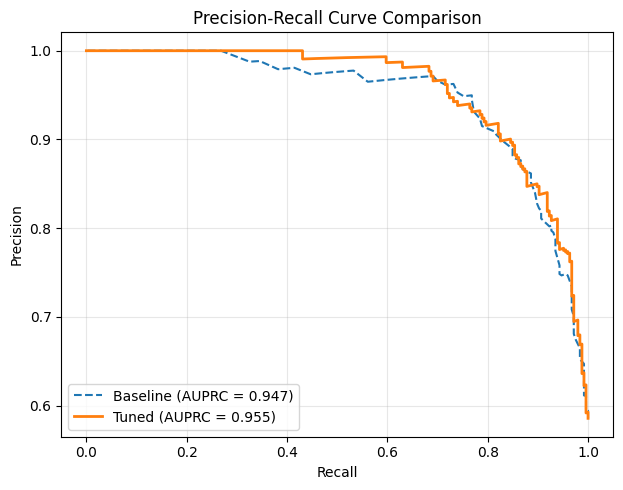

In [11]:
# PR curves
prec_base, rec_base, _ = precision_recall_curve(y_test, baseline_proba)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, tuned_proba)
pr_auc_base = auc(rec_base, prec_base)
pr_auc_tuned = auc(rec_tuned, prec_tuned)

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.plot(rec_base, prec_base, label=f'Baseline (AUPRC = {pr_auc_base:.3f})', linestyle='--')
plt.plot(rec_tuned, prec_tuned, label=f'Tuned (AUPRC = {pr_auc_tuned:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Save models
joblib.dump(baseline_pipe, 'baseline_rf.pkl')
joblib.dump(best_model, 'tuned_rf.pkl')

['tuned_rf.pkl']